# Monocle3 — *C. elegans* L2 (Python port)

Python port of the R vignette `c_elegans_L2_v2.ipynb`. Covers preprocessing, `plot_pc_variance_explained`, batch correction, clustering, marker detection, partition → cell-type assignment, and Garnett marker file generation on the Cao et al. 2017 L2 worm atlas (42035 cells × 20271 genes).


## 1. Setup

In [1]:
import numpy as np 
import pandas as pd

import monocle3 as m3
print('monocle3-python', m3.__version__)

monocle3-python 1.4.26


In [2]:
%config InlineBackend.figure_format = 'retina'

## 2. Load L2 worm data (Cao et al. 2017)

In [3]:
adata = m3.load_cao_l2()
m3.estimate_size_factors(adata)
adata

AnnData object with n_obs × n_vars = 42035 × 20271
    obs: 'plate', 'cao_cluster', 'cao_cell_type', 'cao_tissue', 'Size_Factor'
    var: 'gene_short_name'

## 3. Preprocess (size-factor + PCA) and inspect variance

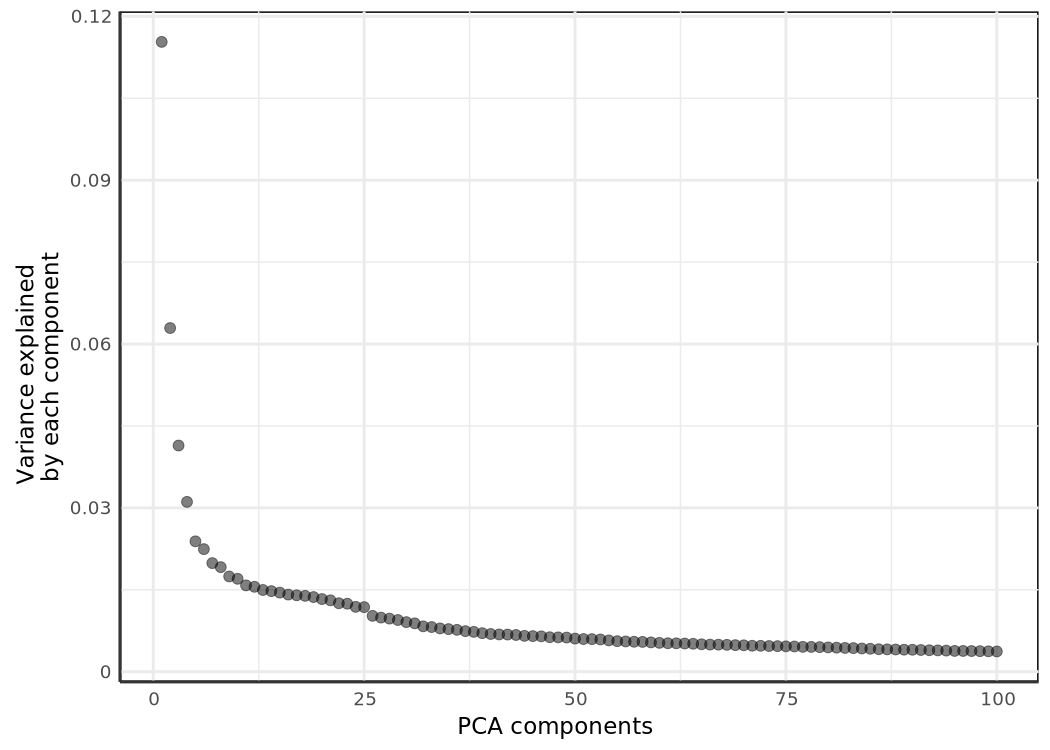

In [4]:
m3.preprocess_cds(adata, num_dim=100)
m3.plot_pc_variance_explained(adata)

## 4. UMAP (before batch correction) — shows the `plate` batch effect

In [5]:
m3.reduce_dimension(adata)

AnnData object with n_obs × n_vars = 42035 × 20271
    obs: 'plate', 'cao_cluster', 'cao_cell_type', 'cao_tissue', 'Size_Factor'
    var: 'gene_short_name'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_umap'

In [6]:
adata.obs['cao_cell_type'].unique().tolist()

['Unclassified neurons',
 'Germline',
 'Intestinal/rectal muscle',
 'Vulval precursors',
 'Coelomocytes',
 nan,
 'Ciliated sensory neurons',
 'Failed QC',
 'Seam cells',
 'Non-seam hypodermis',
 'Pharyngeal epithelia',
 'Touch receptor neurons',
 'Body wall muscle',
 'Cholinergic neurons',
 'Distal tip cells',
 'Other interneurons',
 'GABAergic neurons',
 'Am/PH sheath cells',
 'Pharyngeal muscle',
 'Pharyngeal neurons',
 'Oxygen sensory neurons',
 'Somatic gonad precursors',
 'flp-1(+) interneurons',
 'Canal associated neurons',
 'Unclassified glia',
 'Pharyngeal gland',
 'Sex myoblasts',
 'Excretory cells',
 'Dopaminergic neurons',
 'Socket cells',
 'Rectum']

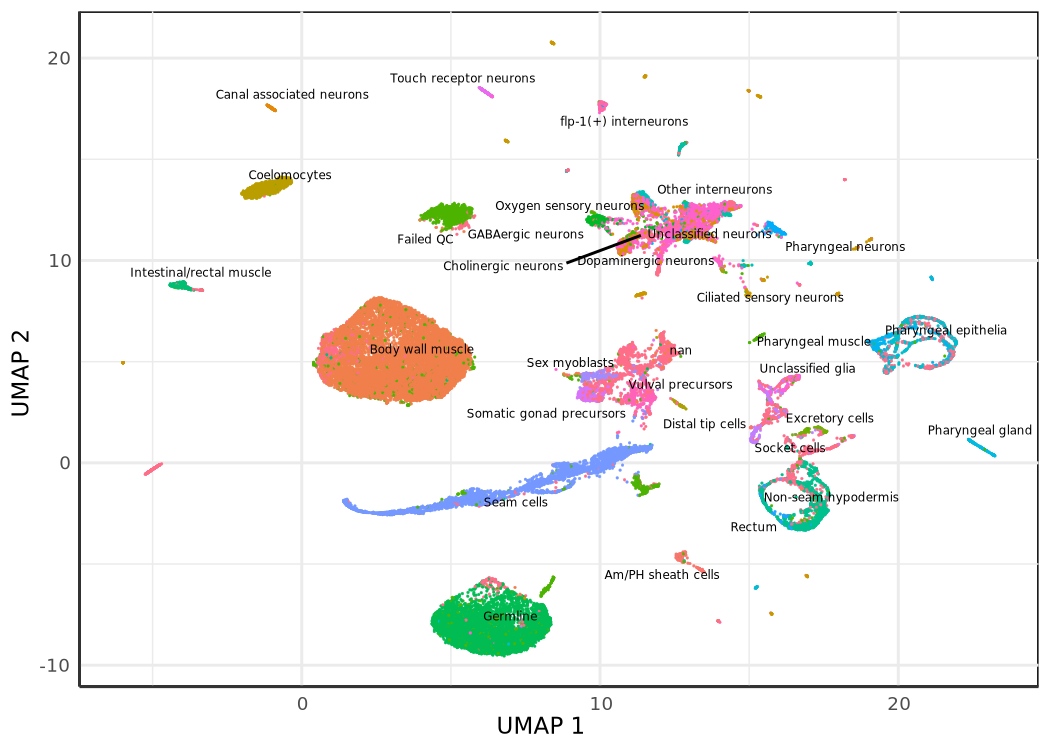

In [7]:
m3.plot_cells(adata, color_cells_by='cao_cell_type', show_trajectory_graph=False, label_cell_groups=True, label_groups_by_cluster=False)

In [8]:
adata.obs['plate'] = adata.obs['plate'].astype('category')

/tmp/ipykernel_41706/316178172.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False, label_groups_by_cluster=False)


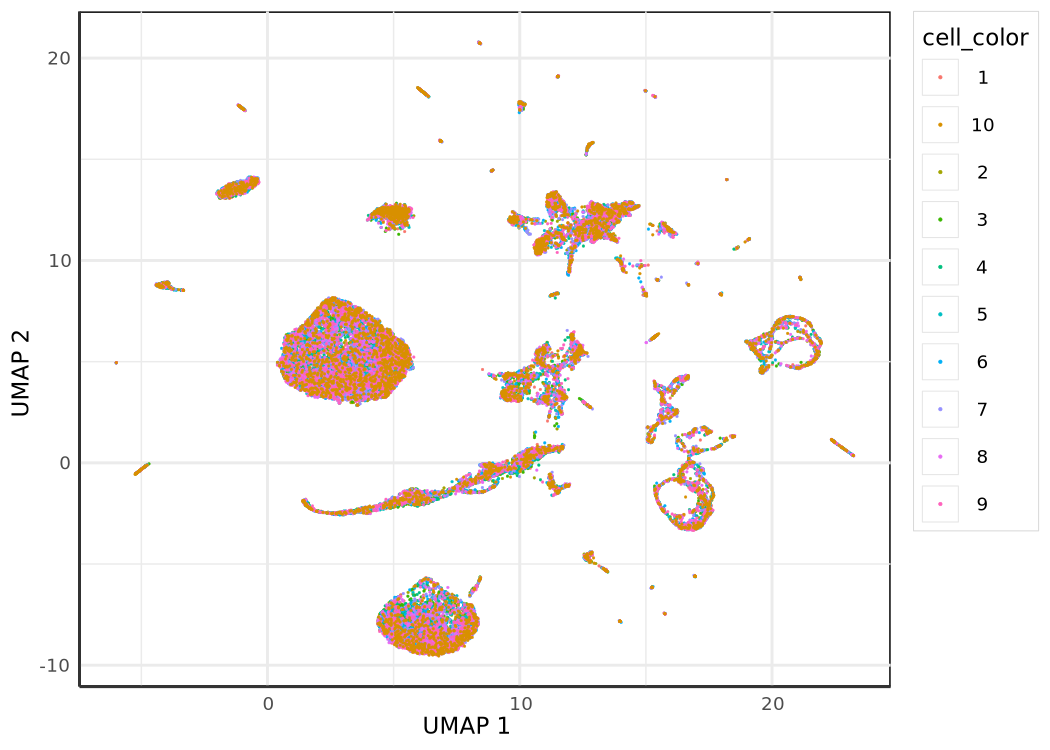

In [9]:
m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False, label_groups_by_cluster=False)

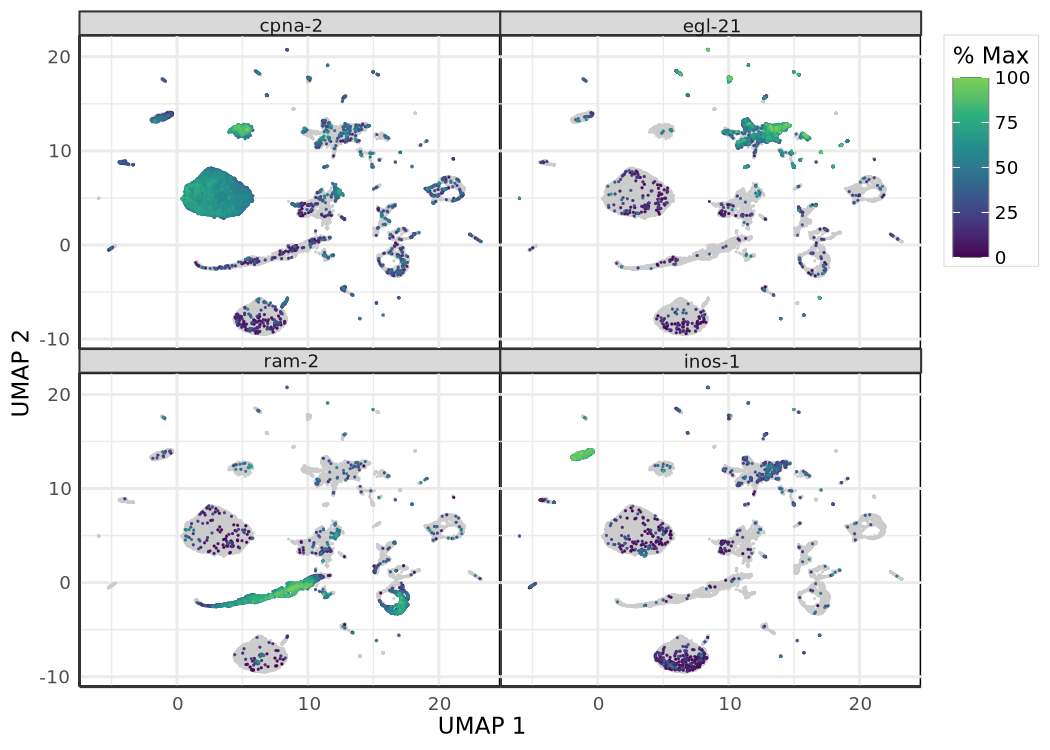

In [10]:
m3.plot_cells(adata, genes=['cpna-2', 'egl-21', 'ram-2', 'inos-1'], show_trajectory_graph=False)

## 5. Align on `plate` and re-embed — batch effect is removed

In [11]:
m3.align_cds(adata, alignment_group='plate')
m3.reduce_dimension(adata, cores=1)

Found 100 genes among all datasets
[[0.         0.65141879 0.42735043 0.42074364 0.50954012 0.43395303
  0.38625245 0.3906628  0.32289628 0.29847054]
 [0.         0.         0.42529915 0.40562956 0.5277708  0.45136969
  0.39733601 0.39138849 0.32998241 0.31466487]
 [0.         0.         0.         0.47487179 0.42222222 0.37367521
  0.33162393 0.31179487 0.25230769 0.24991453]
 [0.         0.         0.         0.         0.42402402 0.38648649
  0.32762763 0.31351351 0.26606607 0.25645646]
 [0.         0.         0.         0.         0.         0.62577921
  0.56344259 0.52007741 0.50447501 0.4925776 ]
 [0.         0.         0.         0.         0.         0.
  0.58448348 0.56119981 0.52433966 0.52316689]
 [0.         0.         0.         0.         0.         0.
  0.         0.59966134 0.59681292 0.56747638]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.60008732 0.59559154]
 [0.         0.         0.         0.         0.         0.
  0.     

/tmp/ipykernel_41706/4007712755.py:2: UserWarning: No preprocess_method specified, and aligned coordinates have been computed previously. Using preprocess_method = 'Aligned'
  m3.reduce_dimension(adata, cores=1)


AnnData object with n_obs × n_vars = 42035 × 20271
    obs: 'plate', 'cao_cluster', 'cao_cell_type', 'cao_tissue', 'Size_Factor'
    var: 'gene_short_name'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_umap', 'X_aligned'

/tmp/ipykernel_41706/1269585316.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)


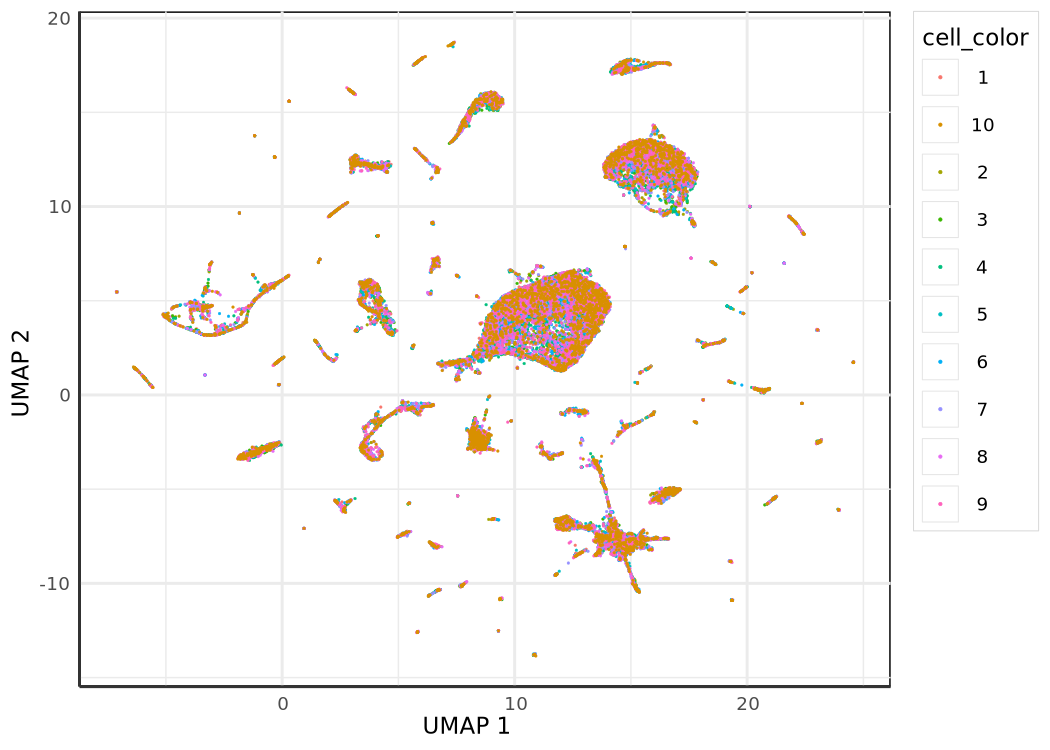

In [12]:
m3.plot_cells(adata, color_cells_by='plate', label_cell_groups=False)

/tmp/ipykernel_41706/1995899236.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='cao_cell_type', label_groups_by_cluster=False)


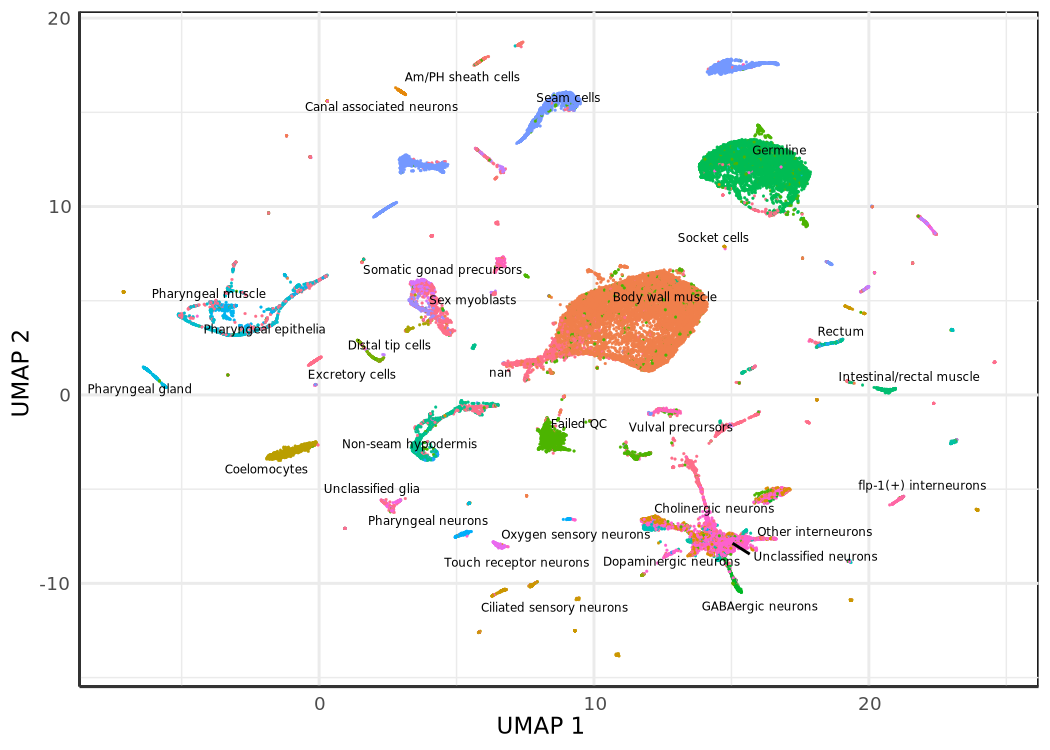

In [13]:
m3.plot_cells(adata, color_cells_by='cao_cell_type', label_groups_by_cluster=False)

## 6. Cluster cells + partition-level structure

In [14]:
m3.cluster_cells(adata, resolution=0.2)

AnnData object with n_obs × n_vars = 42035 × 20271
    obs: 'plate', 'cao_cluster', 'cao_cell_type', 'cao_tissue', 'Size_Factor', 'monocle3_clusters', 'monocle3_partitions'
    var: 'gene_short_name'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_umap', 'X_aligned'

/tmp/ipykernel_41706/4015301464.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, color_cells_by='partition', group_cells_by='partition')


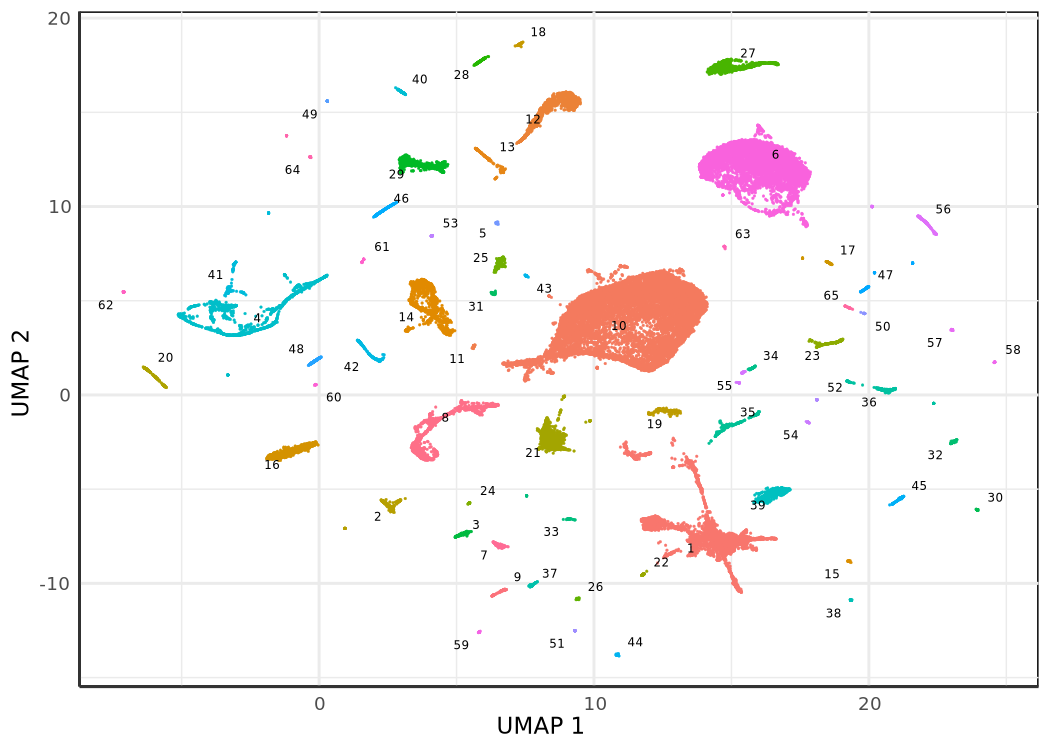

In [15]:
m3.plot_cells(adata, color_cells_by='partition', group_cells_by='partition')

## 7. Top marker genes per partition

In [16]:
marker_test_res = m3.top_markers(
    adata, group_cells_by='partition', reference_cells=1000, cores=8,
)
marker_test_res.head()

/scratch/groups/xiaojie/nianping_scratch/Test_Monocle3/monocle3-python/monocle3/find_markers.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, ca

,gene_id,cell_group,marker_score,specificity,mean_expression,fraction_expressing,pseudo_R2,marker_test_p_value,marker_test_q_value,gene_short_name
0,WBGene00018468,1,0.041802,0.070971,3.933393,0.588997,0.107792,3.873227e-86,5.103421e-80,tag-80
1,WBGene00003753,1,0.037441,0.320257,0.502108,0.116909,0.050135,2.407113e-40,3.171649e-34,nlp-15
2,WBGene00006812,1,0.036595,0.093308,2.063054,0.392193,0.088620,9.630082e-71,1.268874e-64,unc-80
3,WBGene00006780,1,0.032862,0.053164,4.308979,0.618123,0.044814,3.435566e-36,4.526754e-30,unc-44
4,WBGene00006831,1,0.030868,0.090788,1.677682,0.340008,0.069390,1.793813e-55,2.363555e-49,unc-104


In [17]:
top_specific_markers = (
    marker_test_res.query('fraction_expressing >= 0.10')
    .sort_values('pseudo_R2', ascending=False)
    .groupby('cell_group', as_index=False)
    .head(3)
)
top_specific_marker_ids = pd.unique(top_specific_markers['gene_id']).tolist()

In [18]:
p = m3.plot_genes_by_group(
    adata, top_specific_marker_ids,
    group_cells_by='partition',
    ordering_type='cluster_row_col',
    max_size=3,
)

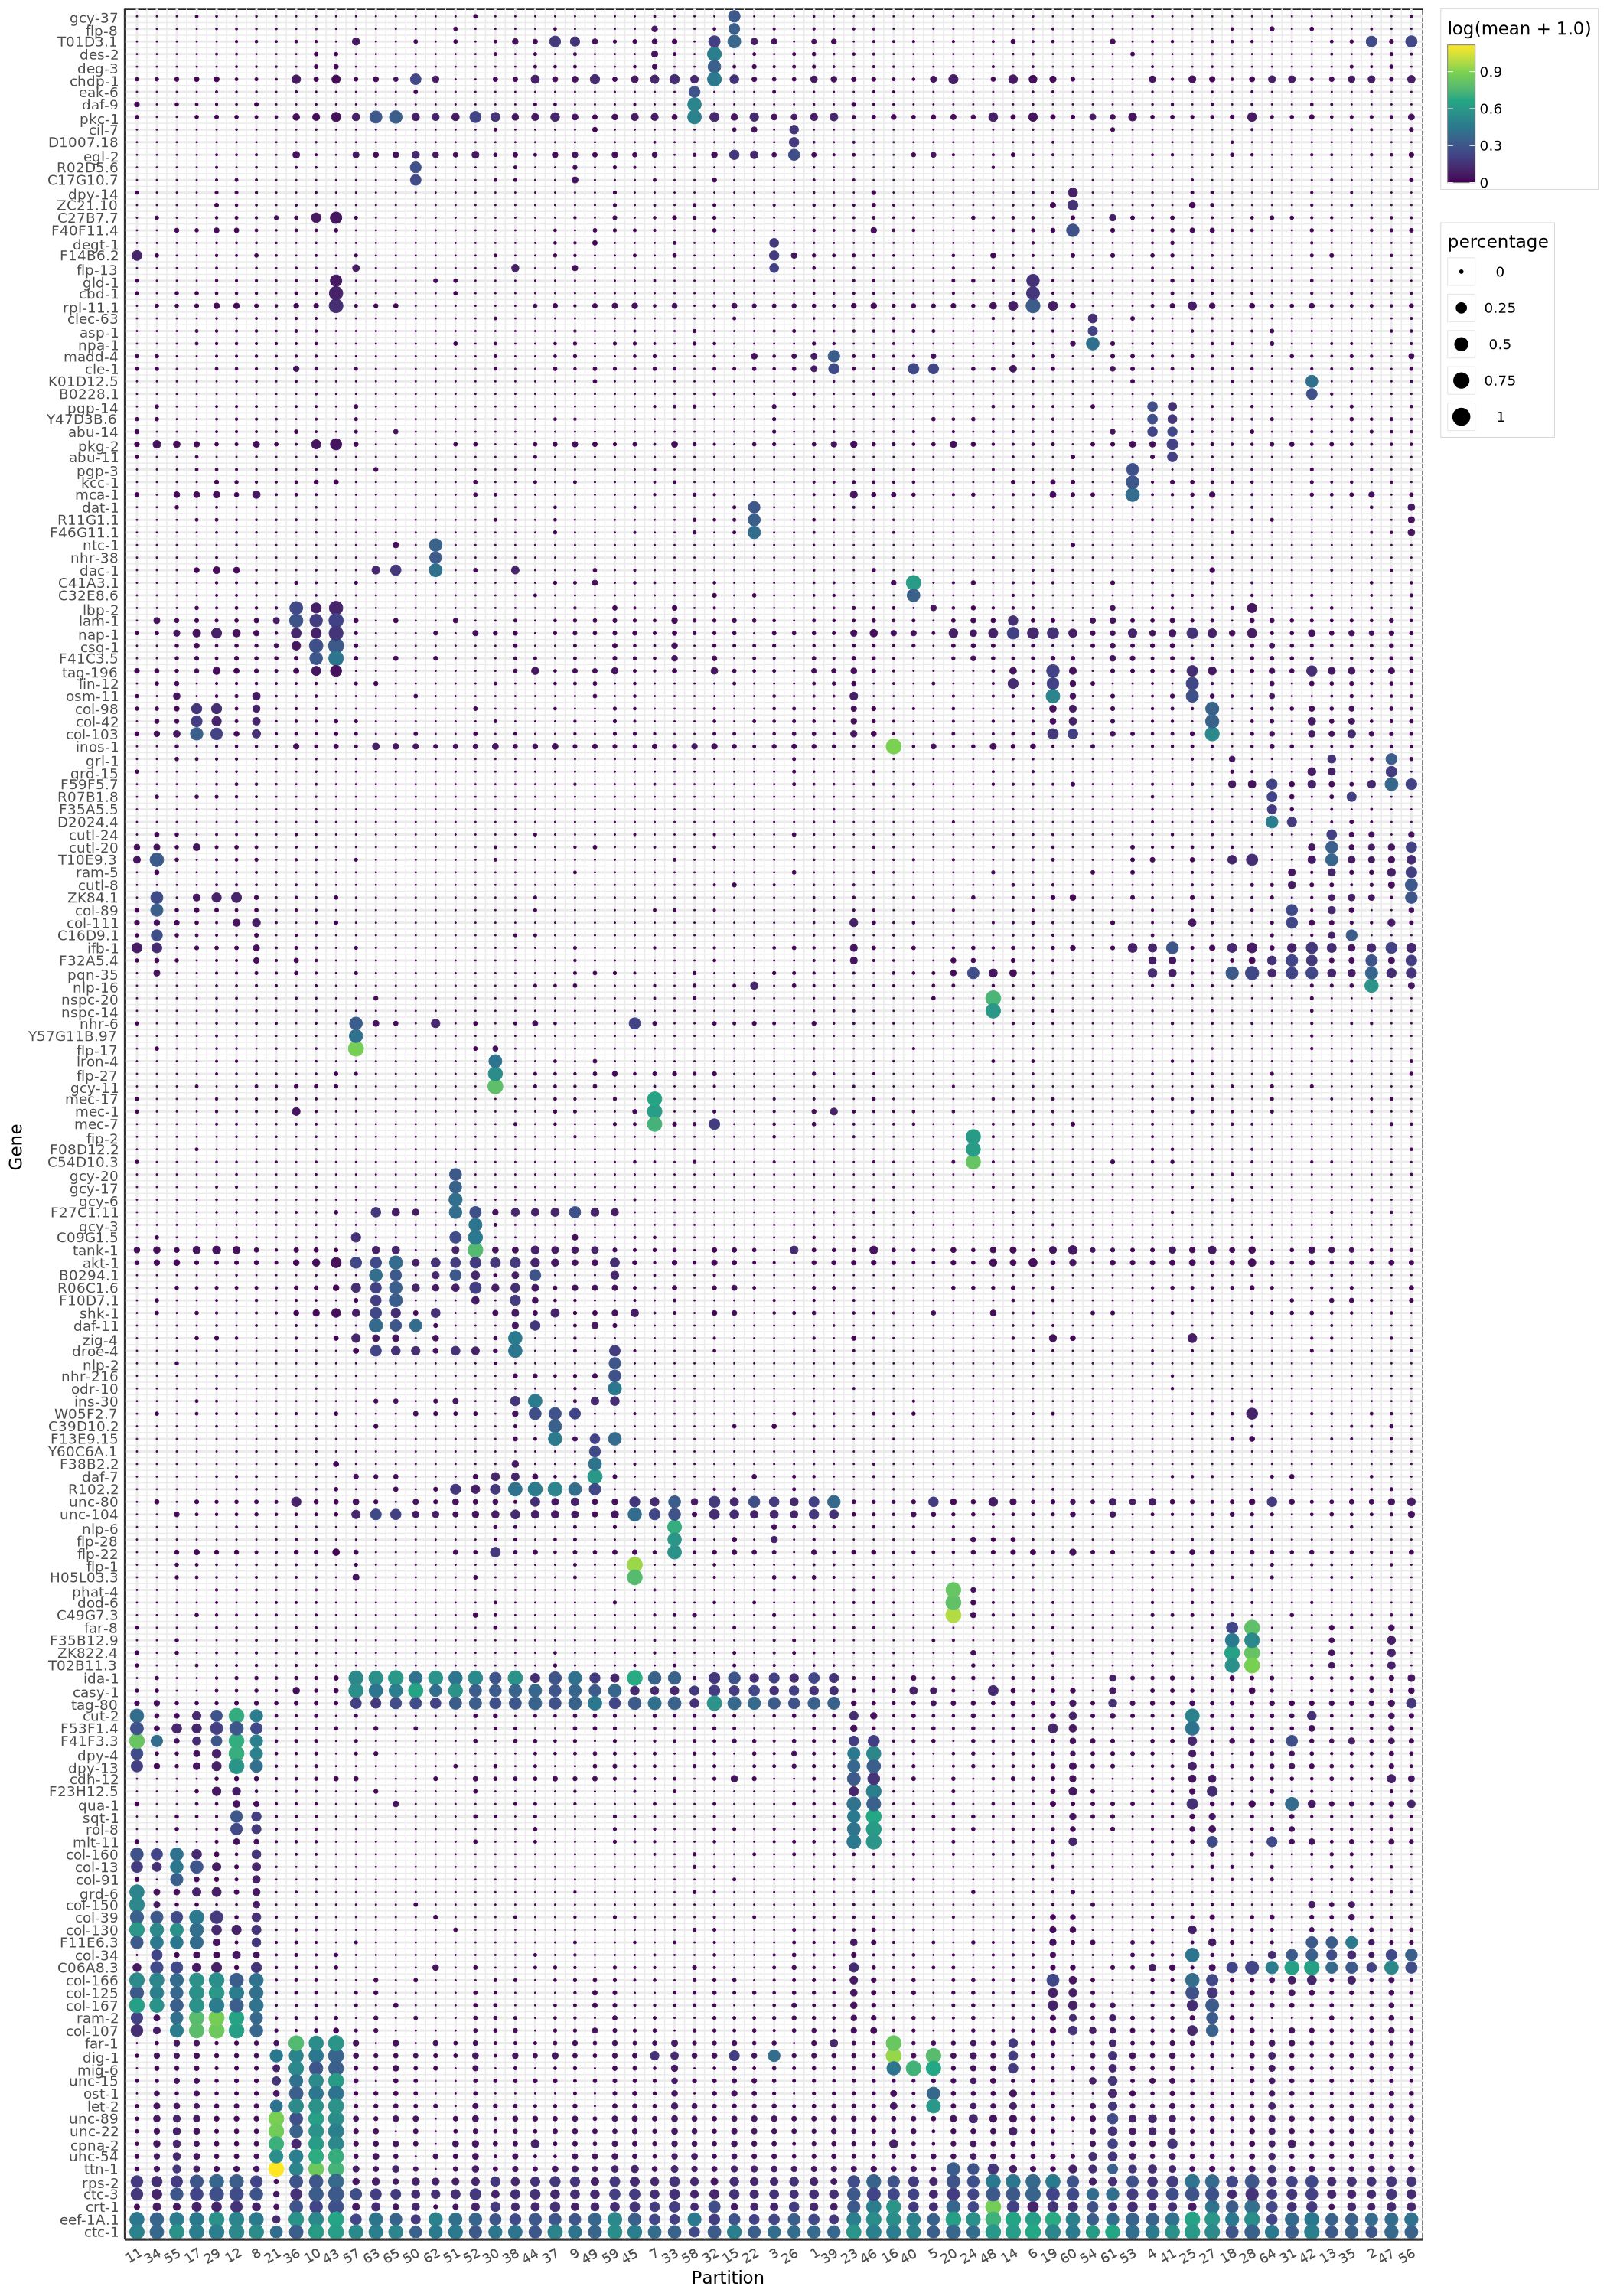

In [19]:
p.fig_width  = 14                                                                                                                                                                                                             
p.fig_height = 20   
p.fig_dpi    = 150
p

## 8. Auto-label partitions by majority `cao_cell_type`

The upstream tutorial hand-recodes partition IDs 1–34 into cell-type names. Our clustering won't reproduce those IDs, so we pick the majority `cao_cell_type` per partition programmatically.

/tmp/ipykernel_41706/900360489.py:7: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, group_cells_by='partition', color_cells_by='assigned_cell_type')


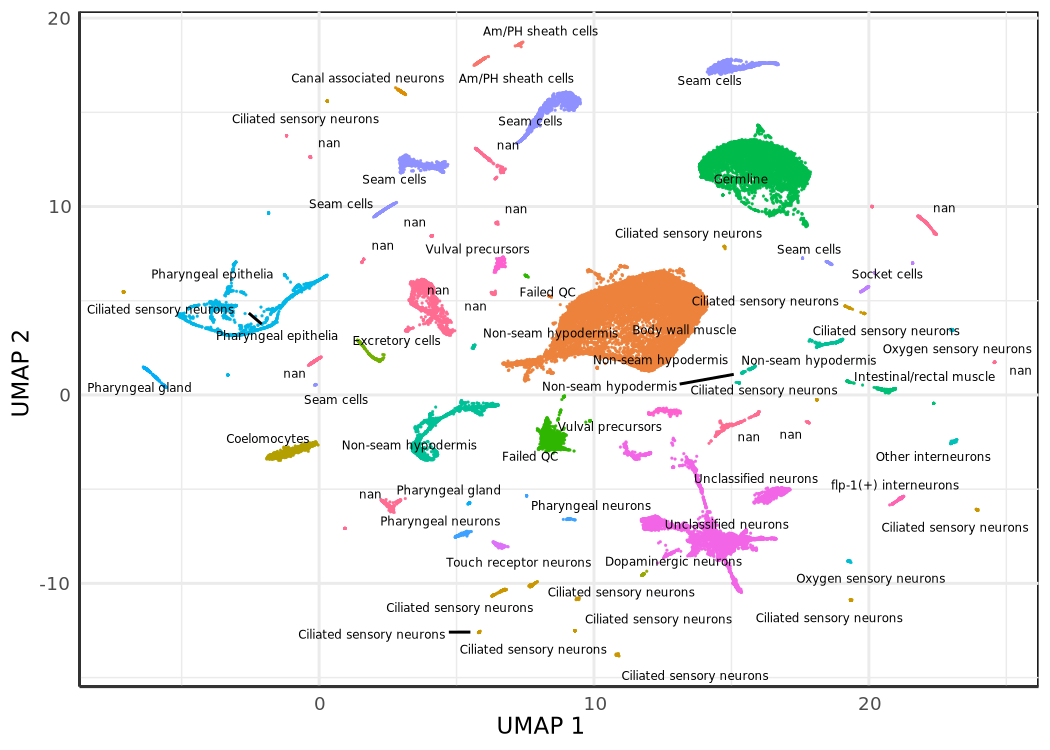

In [20]:
parts = m3.partitions(adata).astype(str)
cross = pd.crosstab(parts, adata.obs['cao_cell_type'].astype(str))
cross_prop = cross.div(cross.sum(axis=1), axis=0).fillna(0)
partition_to_type = cross_prop.idxmax(axis=1).to_dict()

adata.obs['assigned_cell_type'] = parts.map(partition_to_type)
m3.plot_cells(adata, group_cells_by='partition', color_cells_by='assigned_cell_type')

## 9. Re-run `top_markers` on `assigned_cell_type` → Garnett marker file

In [21]:
assigned_mask = adata.obs['assigned_cell_type'].notna().to_numpy()
assigned_adata = adata[assigned_mask].copy()
assigned_type_marker_test_res = m3.top_markers(
    assigned_adata,
    group_cells_by='assigned_cell_type',
    reference_cells=1000, cores=8,
)

garnett_markers = (
    assigned_type_marker_test_res.query(
        'marker_test_q_value < 0.01 & specificity >= 0.5'
    )
    .sort_values('marker_score', ascending=False)
    .groupby('cell_group', as_index=False)
    .head(5)
)
# Remove duplicates that mark multiple groups.
garnett_markers = garnett_markers.groupby('gene_short_name', as_index=False) \
    .filter(lambda g: len(g) == 1)

m3.generate_garnett_marker_file(garnett_markers, file='./marker_file.txt')

/scratch/groups/xiaojie/nianping_scratch/Test_Monocle3/monocle3-python/monocle3/find_markers.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_41706/1206437522.py:21: UserWarning: Group name 'Cell type flp-1(+) interneurons' contained illegal characters; using 'Cell type flp-1.+. interneurons'.
  m3.generate_garnett_marker_file(garnett_markers, file='./marker_file.txt')
